In [818]:
import torch 
import torch.nn as nn 
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch.optim as optim 
import torch.nn.functional as F 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from imblearn.over_sampling import SMOTE

In [819]:
df = pd.read_csv('customer_churn_data.csv')

In [820]:
print(df.head())

  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   CUST0000    Male              0      No        Yes      23           No   
1   CUST0001  Female              0     Yes         No      43           No   
2   CUST0002    Male              1      No         No      51          Yes   
3   CUST0003    Male              1      No         No      72          Yes   
4   CUST0004    Male              1      No         No      25          Yes   

      MultipleLines InternetService       OnlineSecurity  ...  \
0  No phone service              No  No internet service  ...   
1  No phone service             DSL                  Yes  ...   
2                No             DSL                   No  ...   
3               Yes             DSL                  Yes  ...   
4               Yes             DSL                   No  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0  No internet service  No internet service  No internet service  

In [821]:
print(df.shape)

(5880, 21)


In [822]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   str    
 1   gender            5880 non-null   str    
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   str    
 4   Dependents        5880 non-null   str    
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   str    
 7   MultipleLines     5880 non-null   str    
 8   InternetService   5880 non-null   str    
 9   OnlineSecurity    5880 non-null   str    
 10  OnlineBackup      5880 non-null   str    
 11  DeviceProtection  5880 non-null   str    
 12  TechSupport       5880 non-null   str    
 13  StreamingTV       5880 non-null   str    
 14  StreamingMovies   5880 non-null   str    
 15  Contract          5880 non-null   str    
 16  PaperlessBilling  5880 non-null   str    
 17  Paymen

In [823]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    5880.000000  5880.000000     5880.000000   5880.000000
mean        0.500680    36.549150       70.157779   2566.813165
std         0.500042    20.909674       28.804615   1910.017743
min         0.000000     1.000000       20.000000     20.030000
25%         0.000000    18.000000       45.717500   1020.217500
50%         1.000000    37.000000       70.155000   2136.445000
75%         1.000000    55.000000       95.457500   3767.665000
max         1.000000    72.000000      119.990000   8589.600000


gotta scale the totalCharges


In [824]:
print(df.nunique())

customerID          5880
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      4439
TotalCharges        5794
Churn                  2
dtype: int64


In [825]:
df.drop('customerID',axis = 1, inplace=  True)

In [826]:

binary_cols = []
multi_cols = []
numeric_cols = []

for col in df.columns:
    if df[col].dtype == 'str':  
        nunique = df[col].nunique()
        if nunique == 2:
            binary_cols.append(col)
        elif nunique >= 3:
            multi_cols.append(col)
    else:
        numeric_cols.append(col)

print("Binary categorical columns:", binary_cols)
print("Multi-class categorical columns:", multi_cols)
print("Numeric columns:", numeric_cols)

Binary categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Multi-class categorical columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [827]:
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    

In [828]:
col = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [829]:
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        0           1      23             0   
1       0              0        1           0      43             0   
2       1              1        0           0      51             1   
3       1              1        0           0      72             1   
4       1              1        0           0      25             1   

      MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
0  No phone service              No  No internet service  No internet service   
1  No phone service             DSL                  Yes                   No   
2                No             DSL                   No                  Yes   
3               Yes             DSL                  Yes                   No   
4               Yes             DSL                   No                   No   

      DeviceProtection          TechSupport          StreamingTV  \
0  No internet ser

In [830]:
df2 = pd.get_dummies(df, drop_first=True, dtype=int)

In [831]:
print(df2.shape)

(5880, 31)


In [832]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2[col] =  scaler.fit_transform(df2[col])


In [833]:
X_train, X_test, y_train, y_test = train_test_split(
    df2.iloc[:, :-1],  
    df2.iloc[:, -1],    
    test_size=0.3,
    random_state=42
)

In [834]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [835]:
print(y_train.value_counts())

PaymentMethod_Mailed check
0    3099
1    1017
Name: count, dtype: int64


In [836]:
print(y_test.value_counts())

PaymentMethod_Mailed check
0    1319
1     445
Name: count, dtype: int64


In [837]:
class ANN(nn.Module):
    def __init__(self, input_size):
        super(ANN, self).__init__()

        self.fc0 =  nn.Linear(input_size,264)
        self.bn0 = nn.BatchNorm1d(264)
        self.drop0 = nn.Dropout(0.2)

        self.fc1 = nn.Linear(264, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.drop2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.drop3 = nn.Dropout(0.2)
        

        self.fc4 = nn.Linear(32, 16)
        self.bn4 = nn.BatchNorm1d(16)
        self.drop4 = nn.Dropout(0.2)

        self.fc5 = nn.Linear(16,8)

        self.fc6 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.drop0(F.leaky_relu(self.bn0(self.fc0(x))))
        x = self.drop1(F.relu((self.bn1(self.fc1(x)))))
        x = self.drop2(F.leaky_relu(self.bn2(self.fc2(x))))
        x = self.drop3(F.leaky_relu(self.bn3(self.fc3(x))))
        x = self.drop4(F.relu(self.bn4(self.fc4(x))))
        x = F.leaky_relu(self.fc5(x))
        x = self.fc6(x)  
        return x

In [838]:
X_tensor_train = torch.tensor(X_train.values, dtype=torch.float32)
y_tensor_train = torch.tensor(y_train.values, dtype=torch.float32)
y_tensor_train = y_tensor_train.reshape(-1, 1)


In [839]:
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)

In [840]:

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [841]:
batch_size = 64


model = ANN(input_size=30)

In [842]:
learning_rate = 0.001

In [843]:
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()

pos_weight = torch.tensor([num_neg * 1.75 /(num_pos)], dtype=torch.float32)

In [844]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

In [845]:
loss_arr = []


In [846]:
epochs =  2000

In [847]:
print("Before:", y_tensor_train.shape)
y_tensor_train = y_tensor_train.reshape(-1, 1)
print("After:", y_tensor_train.shape)

Before: torch.Size([4116, 1])
After: torch.Size([4116, 1])


In [848]:

for epoch in range(epochs):
    model.train()
    train_loss = 0 
    for X_batch,y_batch in train_loader : 
        outputs = model(X_batch)
        loss = criterion(outputs ,y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        loss_arr.append(train_loss)
    print(f'loss at the {epoch} is {train_loss}')



loss at the 0 is 92.9908264875412
loss at the 1 is 71.3586460351944
loss at the 2 is 56.309972167015076
loss at the 3 is 49.88330566883087
loss at the 4 is 47.42571312189102
loss at the 5 is 45.92462754249573
loss at the 6 is 46.79946109652519
loss at the 7 is 46.01377785205841
loss at the 8 is 45.67892810702324
loss at the 9 is 45.42391365766525
loss at the 10 is 45.37970304489136
loss at the 11 is 45.04676377773285
loss at the 12 is 44.138218089938164
loss at the 13 is 45.34388953447342
loss at the 14 is 45.20033514499664
loss at the 15 is 44.76277828216553
loss at the 16 is 44.09938955307007
loss at the 17 is 43.96948793530464
loss at the 18 is 43.973645597696304
loss at the 19 is 44.75606793165207
loss at the 20 is 44.38062825798988
loss at the 21 is 44.09768134355545
loss at the 22 is 44.022761046886444
loss at the 23 is 43.943459302186966
loss at the 24 is 43.78454211354256
loss at the 25 is 43.174764424562454
loss at the 26 is 42.95579397678375
loss at the 27 is 44.4496171176433

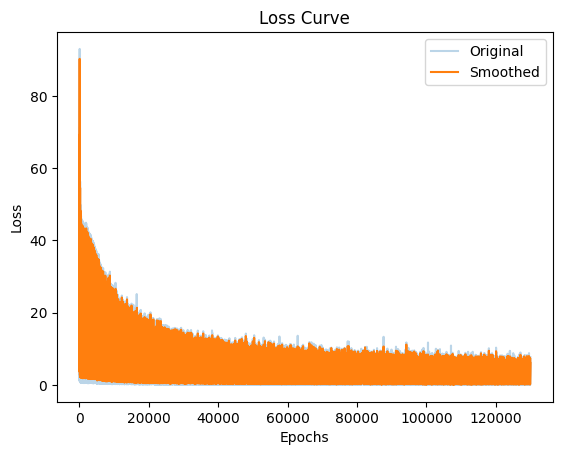

In [849]:
import numpy as np
import matplotlib.pyplot as plt

loss_arr = np.array(loss_arr)

window = 5  
smoothed = np.convolve(loss_arr, np.ones(window)/window, mode='valid')

plt.plot(loss_arr, alpha=0.3, label="Original")   
plt.plot(smoothed, label="Smoothed")              

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Loss Curve")
plt.legend()
plt.show()

In [850]:
model.eval()

num_correct = 0
num_samples = 0

with torch.no_grad():
    outputs = model(X_tensor_train)
    
    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()   

    num_correct = (preds == y_tensor_train).sum().item()
    num_samples = y_tensor_train.shape[0]

accuracy = num_correct / num_samples

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9942


In [851]:
X_tensor_test = torch.tensor(X_test.values, dtype=torch.float32)
y_tensor_test = torch.tensor(y_test.values, dtype=torch.float32)

In [852]:
test_num_correct = 0 
res = []
test_num_samples = 0
with torch.no_grad():
    outputs = model(X_tensor_test)
    preds = torch.sigmoid(outputs)
    preds  = (preds > 0.5 ).float()
    res = preds.numpy()
    test_num_correct = (preds == y_tensor_test).sum().item()
    test_num_samples = y_tensor_test.shape[0]
accuracty = num_correct / num_samples

print(accuracty)

0.9941690962099126


In [853]:
#something supicious here 
from sklearn.metrics import precision_score, recall_score ,f1_score ,confusion_matrix
y_true = y_test.to_numpy()


In [854]:
precision = precision_score(y_true, res)
recall = recall_score(y_true, res)
f1 = f1_score(y_true, res)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.5508637236084453
Recall: 0.6449438202247191
F1 Score: 0.5942028985507246


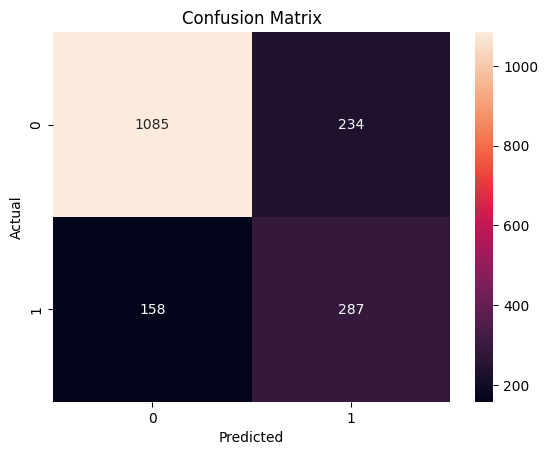

In [855]:
cm = confusion_matrix(y_true, res)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In My model trade off between bias and variance is going so much 

In [856]:
# checking via roc curve in this model 
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, res)
roc_auc = auc(fpr, tpr)

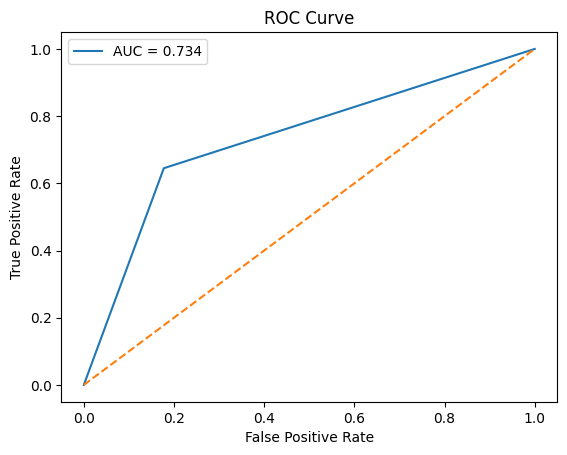

In [857]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

More Recall can be achieved by using bigger coefficient with pos_weight but making complex neural network is not helping me at all right now and one more thing use some better function not relu or leaky relu use better thing then i can take roc at bigger level i max achieved at 0.8 roc and my precision is just stuck till 0.54 and 0.8 was my recall
